# Implied volatility surface (Heston COS - Black–Scholes IV)

Draw Heston parameters with Latin Hypercube Sampling (lhs), price European calls with the COS method and invert Black–Scholes for implied vol on the $(m, \tau)$ grid, use Jäckel’s to solve the IVS. 

- Use latin hypercube to sample Heston parameters
- Simulate heston path dynamics using Milstein discretization
- For each time step treat the Heston-COS as market price then use implied volatility solver to compute the implied volatility at that time step

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from implied_volatility_diffusion.config import merge_config

from implied_volatility_diffusion.synthetic.goals import HestonIvGoal
from implied_volatility_diffusion.synthetic.heston import (
    implied_vol_surfaces_heston_lhs,
    implied_vol_surfaces_heston_sequential_lhs,
    load_heston_iv_surface_config,
    load_heston_iv_surface_goal_config,
)


def _axes_flat(axes):
    if hasattr(axes, "ravel"):
        return list(axes.ravel())
    return [axes]


sns.set_theme(context="notebook", style="ticks")

In [20]:
REPO_ROOT = Path("..").resolve()
CFG_DIR = REPO_ROOT / "config"

# Optional overrides
CFG_OVERRIDES: dict = {
    # "lhs": {"n_samples": 32, "n_batches": 1, "seed": 123},
    # "heston_cos_pricer": {"n_terms": 2048},
    # "market": {"spot": 100.0},
    # "plot_surface": {"zlim": [0.0, 1.0]},
}

CFG_GOAL = HestonIvGoal.SMILE

_base_cfg = (
    load_heston_iv_surface_goal_config(CFG_DIR, CFG_GOAL) if CFG_GOAL else load_heston_iv_surface_config(CFG_DIR)
)
cfg = merge_config(_base_cfg, CFG_OVERRIDES or None)
_lhs_ov = (CFG_OVERRIDES or {}).get("lhs")
if not isinstance(_lhs_ov, dict) or "seed" not in _lhs_ov:
    cfg["lhs"]["seed"] = int(np.random.default_rng().integers(0, 2**31, endpoint=False))

cfg["lhs"]["n_samples"], cfg["lhs"]["seed"]

(100, 593549889)

parameters : https://arxiv.org/pdf/2304.13128

In [ ]:
params, m, tau, iv = implied_vol_surfaces_heston_lhs(cfg)
print("params shape:", params.shape, "-> (n_samples, n_params): Heston LHS parameter samples")
print("iv shape:", iv.shape, "-> (n_samples, n_moneyness, n_tau): IVS for all samples")

## IVS samples

Sequential 3D surfaces and heatmaps.

Generate **one trading year** of IV surfaces `dt = 1/252`, 100 LHS paths.

In [ ]:
import time

M, TAU = np.meshgrid(
    np.asarray(m).ravel(),
    np.asarray(tau).ravel(),
    indexing="ij",
)

ps = cfg.get("plot_surface", {})
z0, z1 = ps.get("zlim", [0.0, 1.0])
iv_norm = Normalize(vmin=z0, vmax=z1)
cmap = ps.get("cmap", "turbo")
elev = ps.get("elev", 30)
azim = ps.get("azim", -42)

TRADING_DAYS_PER_YEAR = 60
DISPLAY_STEP_INTERVAL = 20  # plot IVS every N trading days (full sequence still computed)

seq_surface_cfg = merge_config(
    cfg,
    {
        "lhs": {"n_samples": 1, "n_batches": 100},
        "sequential_ivs": {
            "n_steps": TRADING_DAYS_PER_YEAR,
            "dt": 1.0 / TRADING_DAYS_PER_YEAR,
        },
    },
)

start_time = time.perf_counter()
params_seq, m_seq_chk, tau_seq_chk, iv_seq = implied_vol_surfaces_heston_sequential_lhs(seq_surface_cfg)
end_time = time.perf_counter()
print(f"implied_vol_surfaces_heston_sequential_lhs runtime: {end_time - start_time:.3f} seconds")

if not (np.allclose(np.asarray(m_seq_chk), np.asarray(m)) and np.allclose(np.asarray(tau_seq_chk), np.asarray(tau))):
    raise AssertionError("Sequential grid should match the LHS grid for the same cfg")

ks_sequential_display = list(range(0, iv_seq.shape[1], DISPLAY_STEP_INTERVAL))
if ks_sequential_display[-1] != iv_seq.shape[1] - 1:
    ks_sequential_display.append(iv_seq.shape[1] - 1)

implied_vol_surfaces_heston_sequential_lhs runtime: 2198.331 seconds


### Sequential path: IV surfaces (3D)

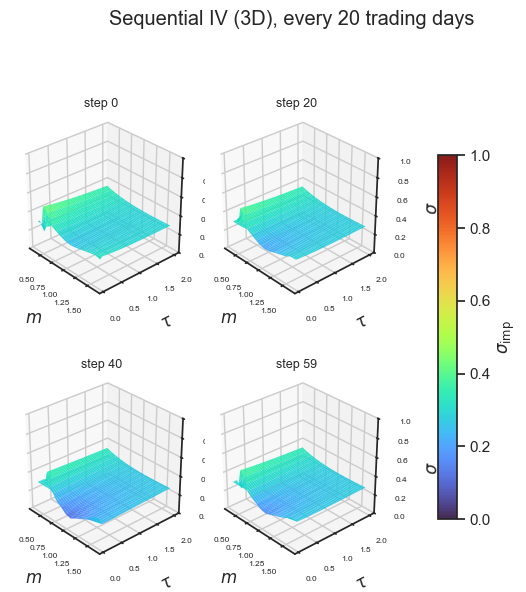

In [ ]:
ks = ks_sequential_display
n = len(ks)
ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)
_cell = 3.0
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(_cell * ncols, _cell * nrows),
    subplot_kw={"projection": "3d"},
)
axes_flat = _axes_flat(axes)
surf_last = None
for i, k in enumerate(ks):
    ax = axes_flat[i]
    Z = iv_seq[0, k]
    surf_last = ax.plot_surface(M, TAU, Z, cmap=cmap, edgecolor="none", alpha=0.9, norm=iv_norm)
    ax.set_zlim(z0, z1)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"step {k}", fontsize=9)
    ax.tick_params(labelsize=6)
    ax.set_xlabel(r"$m$")
    ax.set_ylabel(r"$\tau$")
    ax.set_zlabel(r"$\sigma$")
    try:
        ax.set_box_aspect((1, 1, 1))
    except AttributeError:
        pass
for j in range(n, len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle(f"Sequential IV (3D), every {DISPLAY_STEP_INTERVAL} trading days")
fig.tight_layout(rect=[0, 0, 0.9, 0.96])
if surf_last is not None:
    fig.colorbar(
        surf_last,
        ax=[axes_flat[i] for i in range(n)],
        shrink=0.75,
        pad=0.1,
        label=r"$\sigma_{\mathrm{imp}}$",
    )
plt.show()

### Sequential path: IV heatmap per step

Saved sequential IV heatmaps to /Users/sbonelomdluli/Desktop/implied-volatility-diffusion/notebooks/sequential_ivs.pdf


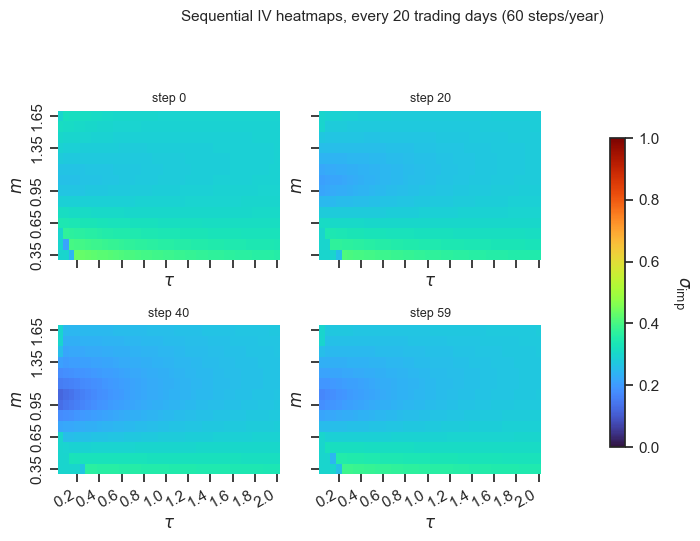

In [ ]:
path_i = 0
ps = cfg.get("plot_surface", {})
cmap = ps.get("cmap", "turbo")
z0, z1 = ps.get("zlim", [0.0, 1.0])
kr = ks_sequential_display
n = len(kr)
ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)
_cell_x, _cell_y = 4.0, 2.75
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(_cell_x * ncols, _cell_y * nrows),
    sharex=True,
    sharey=True,
)
axes_flat = _axes_flat(axes)

for i, k in enumerate(kr):
    ax = axes_flat[i]
    Z = iv_seq[path_i, k]

    # For equal axis spacing, generate linearly spaced values for tau/m
    nrow, ncol = Z.shape
    # Equal-spaced tau/money for pretty axis
    m_axis_eq = np.linspace(float(np.min(m_seq_chk)), float(np.max(m_seq_chk)), nrow)
    tau_axis_eq = np.linspace(float(np.min(tau_seq_chk)), float(np.max(tau_seq_chk)), ncol)

    sns.heatmap(
        Z,
        cmap=cmap,
        vmin=z0,
        vmax=z1,
        ax=ax,
        cbar=False,
        linewidths=0,
        rasterized=True,
        square=False,
    )
    ax.invert_yaxis()
    ax.set_aspect("auto")

    if ncol > 0:
        _t0, _t1 = float(tau_axis_eq[0]), float(tau_axis_eq[-1])
        _step = 0.2
        if ncol == 1:
            ax.set_xticks([0.5])
            ax.set_xticklabels([f"{_t0:.1f}"], rotation=30, ha="right")
        else:
            _tick_start = math.ceil(_t0 / _step - 1e-12) * _step
            _ticks = np.arange(_tick_start, _t1 + 0.5 * _step, _step, dtype=np.float64)
            _ticks = _ticks[(_ticks >= _t0 - 1e-12) & (_ticks <= _t1 + 1e-12)]
            if _ticks.size == 0:
                _ticks = np.array([(_t0 + _t1) / 2], dtype=np.float64)
            _xpos = (_ticks - _t0) / (_t1 - _t0) * (ncol - 1) + 0.5
            ax.set_xticks(_xpos)
            ax.set_xticklabels([f"{v:.1f}" for v in _ticks.tolist()], rotation=30, ha="right")
    if nrow > 0:
        yi = np.linspace(0, nrow - 1, num=min(5, nrow)).round().astype(int).tolist()
        ax.set_yticks([float(j) + 0.5 for j in yi])
        ax.set_yticklabels([f"{m_axis_eq[j]:.3g}" for j in yi])
    ax.set_title(f"step {k}", fontsize=9)
for j in range(n, len(axes_flat)):
    axes_flat[j].axis("off")
_xlabel = r"$\tau$"
_ylabel = r"$m$"
for ax in axes_flat:
    if ax.get_visible() and ax.has_data():
        ax.set_xlabel(_xlabel)
        ax.set_ylabel(_ylabel)
smp = ScalarMappable(cmap=cmap, norm=Normalize(vmin=z0, vmax=z1))
smp.set_array([])
fig.suptitle(
    f"Sequential IV heatmaps, every {DISPLAY_STEP_INTERVAL} trading days ({iv_seq.shape[1]} steps/year)",
    fontsize=11,
    y=1.02,
)
fig.tight_layout(rect=[0, 0.04, 0.82, 0.96])
cbar = fig.colorbar(
    smp,
    ax=[axes_flat[i] for i in range(n)],
    shrink=0.85,
    pad=0.12,
    fraction=0.035,
)
cbar.set_label(r"$\sigma_{\mathrm{imp}}$", rotation=270, labelpad=22)

SEQUENTIAL_IVS_PDF_PATH = REPO_ROOT / "notebooks" / "sequential_ivs.pdf"
SEQUENTIAL_IVS_PDF_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(SEQUENTIAL_IVS_PDF_PATH, bbox_inches="tight", format="pdf")
print(f"Saved sequential IV heatmaps to {SEQUENTIAL_IVS_PDF_PATH}")

plt.show()

### Sequential path: IV surface difference from step 0

The bulk of a Heston surface on the $(m, \tau)$ grid is fixed by the parameter row (through $\theta, \kappa, \sigma_v, \rho, r$); only the current instantaneous variance $v_t$ drives step-to-step motion, and mean reversion damps its effect at long $\tau$. Plotting raw surfaces hides this, so we subtract step 0 to expose the actual dynamics (short-$\tau$ ATM motion dominates).

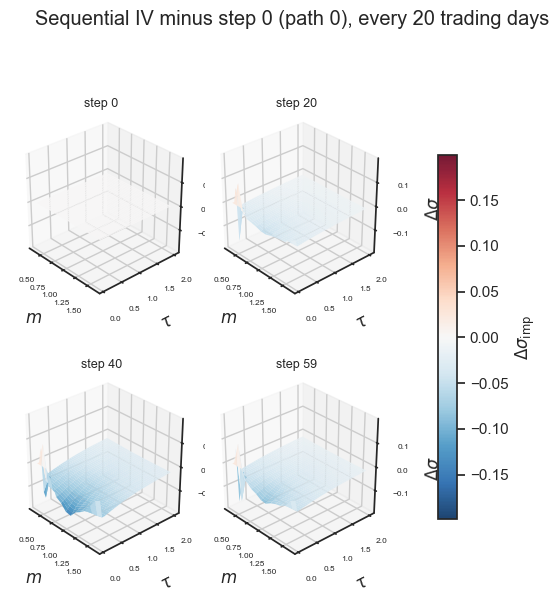

In [ ]:
from matplotlib.colors import TwoSlopeNorm

path_i_diff = 0
base_iv = iv_seq[path_i_diff, 0]
diff_stack = iv_seq[path_i_diff] - base_iv
diff_limit = float(np.nanmax(np.abs(np.asarray(diff_stack))))
diff_limit = max(diff_limit, 1e-6)
diff_norm = TwoSlopeNorm(vmin=-diff_limit, vcenter=0.0, vmax=diff_limit)

ks = ks_sequential_display
n = len(ks)
ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)
_cell = 3.0
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(_cell * ncols, _cell * nrows),
    subplot_kw={"projection": "3d"},
)
axes_flat = _axes_flat(axes)
surf_last = None
for i, k in enumerate(ks):
    ax = axes_flat[i]
    Z_diff = iv_seq[path_i_diff, k] - base_iv
    surf_last = ax.plot_surface(
        M,
        TAU,
        Z_diff,
        cmap="RdBu_r",
        edgecolor="none",
        alpha=0.9,
        norm=diff_norm,
    )
    ax.set_zlim(-diff_limit, diff_limit)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"step {k}", fontsize=9)
    ax.tick_params(labelsize=6)
    ax.set_xlabel(r"$m$")
    ax.set_ylabel(r"$\tau$")
    ax.set_zlabel(r"$\Delta\sigma$")
    try:
        ax.set_box_aspect((1, 1, 1))
    except AttributeError:
        pass
for j in range(n, len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle(f"Sequential IV minus step 0 (path {path_i_diff}), every {DISPLAY_STEP_INTERVAL} trading days")
fig.tight_layout(rect=[0, 0, 0.9, 0.96])
if surf_last is not None:
    fig.colorbar(
        surf_last,
        ax=[axes_flat[i] for i in range(n)],
        shrink=0.75,
        pad=0.1,
        label=r"$\Delta\sigma_{\mathrm{imp}}$",
    )
plt.show()

### LHS path diversity at a fixed trading day

Step-to-step motion within one path is small (Heston is mean-reverting, the grid is $(m, \tau)$ so spot drift is absorbed, and $v_t$ barely moves over $\mathrm{d}t = 1/252$). Diversity across LHS paths, on the other hand, reflects the full parameter cube and is the right thing to train a diffusion model on.

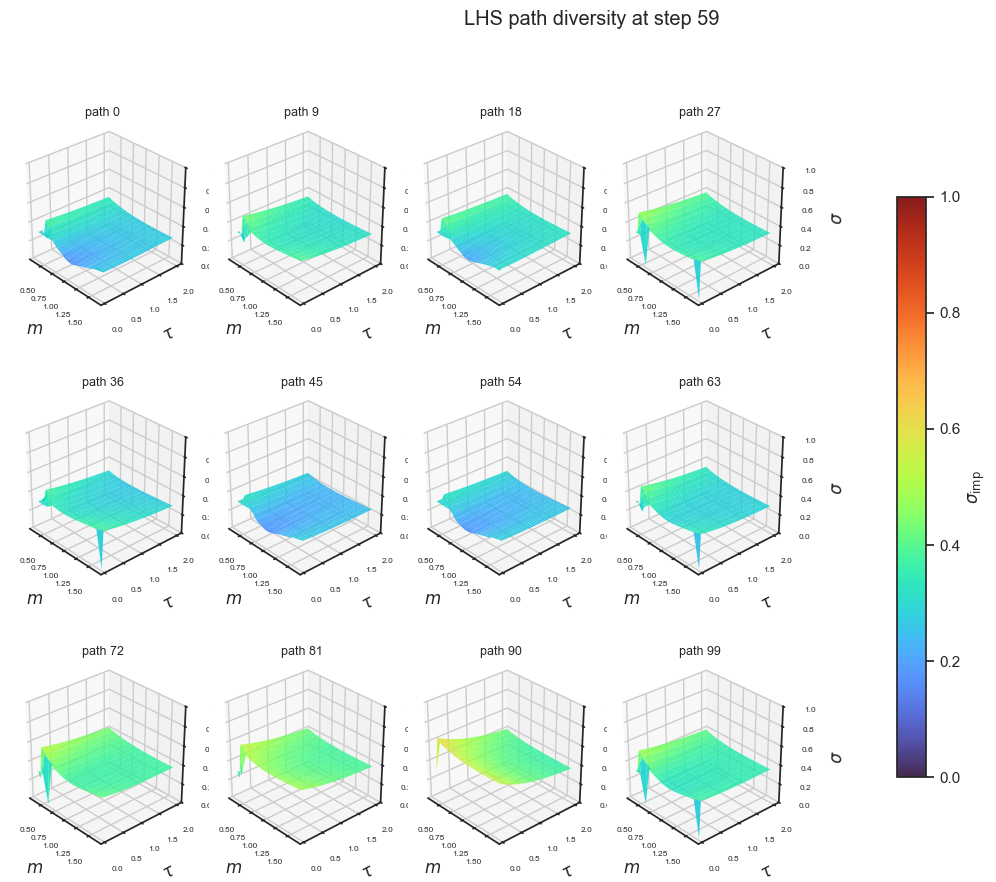

In [ ]:
FIXED_STEP = iv_seq.shape[1] - 1
N_PATHS_SHOW = min(12, iv_seq.shape[0])
path_indices = np.linspace(0, float(iv_seq.shape[0] - 1), N_PATHS_SHOW).round().astype(int).tolist()

ncols = math.ceil(math.sqrt(N_PATHS_SHOW))
nrows = math.ceil(N_PATHS_SHOW / ncols)
_cell = 3.0
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(_cell * ncols, _cell * nrows),
    subplot_kw={"projection": "3d"},
)
axes_flat = _axes_flat(axes)
surf_last = None
for i, p in enumerate(path_indices):
    ax = axes_flat[i]
    Z = iv_seq[p, FIXED_STEP]
    surf_last = ax.plot_surface(M, TAU, Z, cmap=cmap, edgecolor="none", alpha=0.9, norm=iv_norm)
    ax.set_zlim(z0, z1)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"path {p}", fontsize=9)
    ax.tick_params(labelsize=6)
    ax.set_xlabel(r"$m$")
    ax.set_ylabel(r"$\tau$")
    ax.set_zlabel(r"$\sigma$")
    try:
        ax.set_box_aspect((1, 1, 1))
    except AttributeError:
        pass
for j in range(N_PATHS_SHOW, len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle(f"LHS path diversity at step {FIXED_STEP}")
fig.tight_layout(rect=[0, 0, 0.9, 0.96])
if surf_last is not None:
    fig.colorbar(
        surf_last,
        ax=[axes_flat[i] for i in range(N_PATHS_SHOW)],
        shrink=0.75,
        pad=0.1,
        label=r"$\sigma_{\mathrm{imp}}$",
    )
plt.show()

### Cross-sections: IV vs moneyness (LHS batch mean)

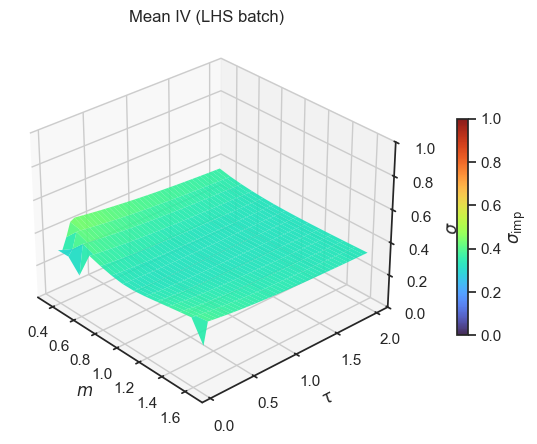

In [ ]:
Z_mean_lhs = np.asarray(iv).mean(axis=0)
ps = cfg.get("plot_surface", {})
z0, z1 = ps.get("zlim", [0.0, 1.0])
iv_norm_mean = Normalize(vmin=z0, vmax=z1)
cmap = ps.get("cmap", "turbo")

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(7, 4.5))
surf = ax.plot_surface(M, TAU, Z_mean_lhs, cmap=cmap, edgecolor="none", alpha=0.9, norm=iv_norm_mean)
ax.set_xlabel(r"$m$")
ax.set_ylabel(r"$\tau$")
ax.set_zlabel(r"$\sigma$")
ax.set_zlim(z0, z1)
ax.view_init(elev=ps.get("elev", 30), azim=ps.get("azim", -42))
ax.set_title("Mean IV (LHS batch)")
plt.tight_layout()
fig.colorbar(surf, ax=ax, shrink=0.55, pad=0.08, label=r"$\sigma_{\mathrm{imp}}$")
plt.show()

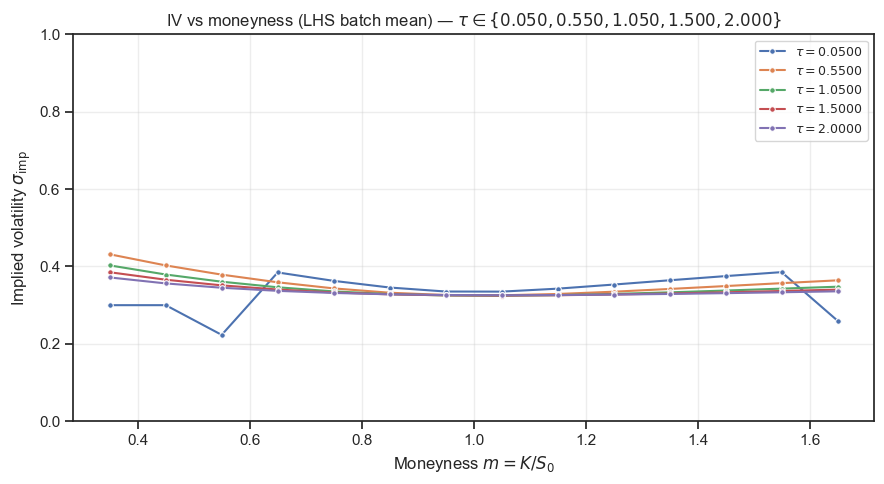

In [ ]:
ps_xs = cfg.get("plot_surface", {})
z0_xs, z1_xs = ps_xs.get("zlim", [0.0, 1.0])

# maturity indices for cross-sections (evenly spaced in tau grid)
num_sections = 5
j_idx = [round(i * (len(tau) - 1) / (num_sections - 1)) for i in range(num_sections)]

fig, ax = plt.subplots(figsize=(9, 5))
rows = []
for j in j_idx:
    tau_lbl = rf"$\tau={tau[j]:.4f}$"
    for mi, mval in enumerate(m):
        rows.append({"m": float(mval), "IV": float(Z_mean_lhs[mi, j]), "tau": tau_lbl})
df_xs = pd.DataFrame.from_records(rows)
sns.lineplot(
    data=df_xs,
    x="m",
    y="IV",
    hue="tau",
    marker="o",
    markersize=4,
    linewidth=1.5,
    ax=ax,
    legend="full",
)
ax.set_xlabel(r"Moneyness $m = K/S_0$")
ax.set_ylabel(r"Implied volatility $\sigma_{\mathrm{imp}}$")
ax.set_title(
    "IV vs moneyness (LHS batch mean) — "
    rf"$\tau \in \{{{', '.join(f'{tau[j]:.3f}' for j in j_idx)}\}}$"
)
ax.set_ylim(z0_xs, z1_xs)
ax.legend(loc="best", fontsize=9, title=None)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

## Random samples

### Independent LHS IVS (For demostration)

In [ ]:
# Independent Heston LHS surfaces — not sequential_ivs
RANDOM_IV_CFG = merge_config(
    cfg,
    {"lhs": {"n_samples": 6, "n_batches": 2, "seed": 440}},
)
params_rand, m_rand, tau_rand, iv_rand = implied_vol_surfaces_heston_lhs(RANDOM_IV_CFG)
if not (np.allclose(np.asarray(m_rand), np.asarray(m)) and np.allclose(np.asarray(tau_rand), np.asarray(tau))):
    raise AssertionError("Random-sample grid should match cfg grid.")
print(
    "iv_rand shape:",
    iv_rand.shape,
    "-> (n_samples, n_moneyness, n_tau): independent Heston LHS surfaces",
)

iv_rand shape: (12, 14, 40) -> (n_samples, n_moneyness, n_tau): independent Heston LHS surfaces


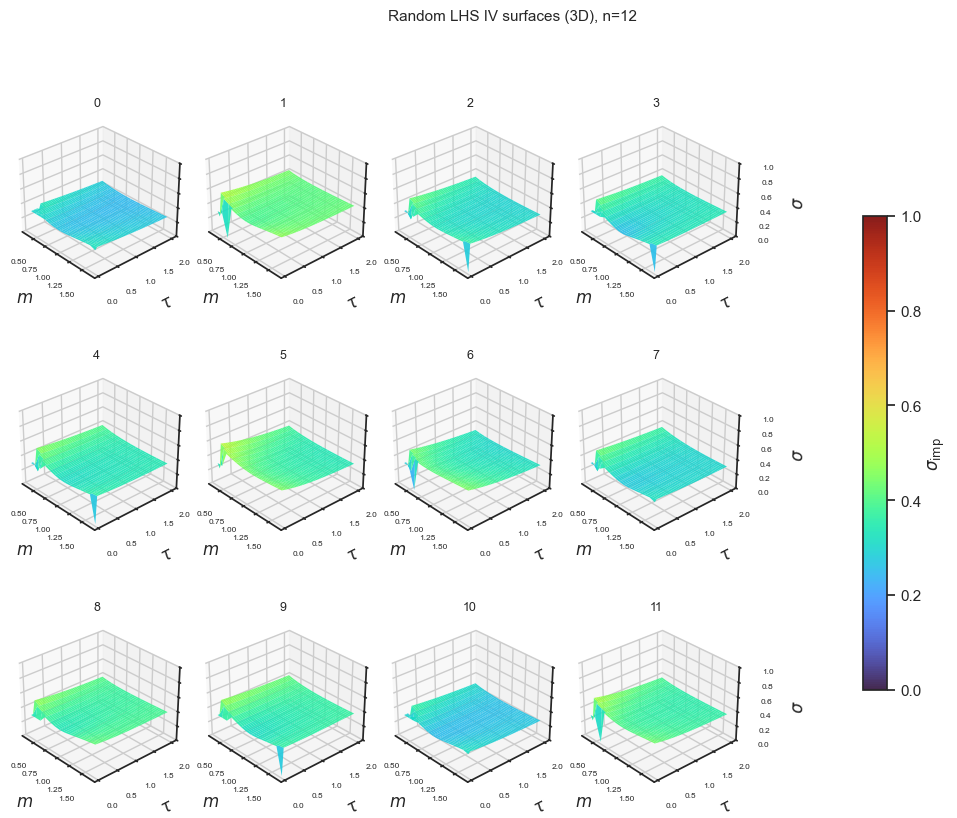

In [ ]:
ps = cfg.get("plot_surface", {})
cmap = ps.get("cmap", "turbo")
z0, z1 = ps.get("zlim", [0.0, 1.0])
iv_norm_rand = Normalize(vmin=z0, vmax=z1)
elev = ps.get("elev", 30)
azim = ps.get("azim", -42)

n_t = iv_rand.shape[0]
ncols = min(4, n_t)
nrows = math.ceil(n_t / ncols)

fig3, axes3 = plt.subplots(
    nrows,
    ncols,
    figsize=(2.6 * ncols, 2.7 * nrows),
    subplot_kw={"projection": "3d"},
)
axes3_flat = _axes_flat(axes3)
surf_last = None
for i in range(n_t):
    ax = axes3_flat[i]
    Z = iv_rand[i]
    surf_last = ax.plot_surface(M, TAU, Z, cmap=cmap, edgecolor="none", alpha=0.9, norm=iv_norm_rand)
    ax.set_zlim(z0, z1)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"{i}", fontsize=9)
    ax.tick_params(labelsize=6)
    ax.set_xlabel(r"$m$")
    ax.set_ylabel(r"$\tau$")
    ax.set_zlabel(r"$\sigma$")
for j in range(n_t, len(axes3_flat)):
    axes3_flat[j].set_visible(False)
fig3.suptitle(f"Random LHS IV surfaces (3D), n={n_t}", fontsize=11, y=1.02)
plt.tight_layout()
if surf_last is not None:
    fig3.colorbar(
        surf_last,
        ax=[axes3_flat[i] for i in range(n_t)],
        shrink=0.65,
        pad=0.12,
        label=r"$\sigma_{\mathrm{imp}}$",
    )
plt.show()

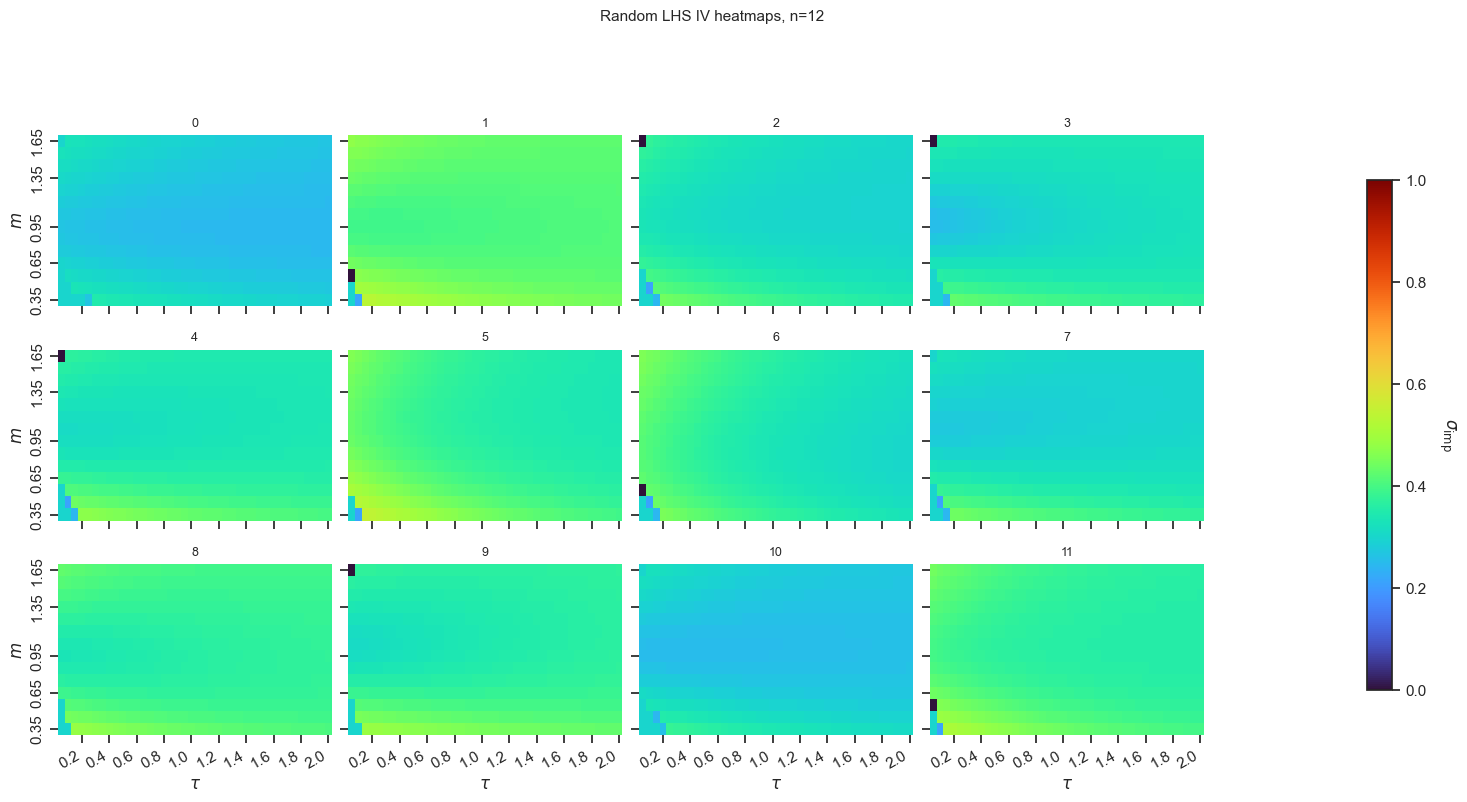

In [ ]:
ps = cfg.get("plot_surface", {})
cmap = ps.get("cmap", "turbo")
z0, z1 = ps.get("zlim", [0.0, 1.0])

n_t = iv_rand.shape[0]
ncols = min(4, n_t)
nrows = math.ceil(n_t / ncols)
_tau_lo, _tau_hi = float(tau.min()), float(tau.max())
_m_lo, _m_hi = float(m.min()), float(m.max())
_cell_x, _cell_y = 4.0, 2.75

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(_cell_x * ncols, _cell_y * nrows),
    sharex=True,
    sharey=True,
)
axes_flat = _axes_flat(axes)
for i in range(n_t):
    ax = axes_flat[i]
    Z = iv_rand[i]
    sns.heatmap(
        Z,
        cmap=cmap,
        vmin=z0,
        vmax=z1,
        ax=ax,
        cbar=False,
        linewidths=0,
        rasterized=True,
        square=False,
    )
    ax.invert_yaxis()
    nrow, ncol = Z.shape
    ax.set_aspect("auto")
    tau_vals = np.linspace(_tau_lo, _tau_hi, ncol)
    m_vals = np.linspace(_m_lo, _m_hi, nrow)
    if ncol > 0:
        _t0, _t1 = _tau_lo, _tau_hi
        _step = 0.2
        if ncol == 1:
            ax.set_xticks([0.5])
            ax.set_xticklabels([f"{_t0:.1f}"], rotation=30, ha="right")
        else:
            _tick_start = math.ceil(_t0 / _step - 1e-12) * _step
            _ticks = np.arange(_tick_start, _t1 + 0.5 * _step, _step, dtype=np.float64)
            _ticks = _ticks[(_ticks >= _t0 - 1e-12) & (_ticks <= _t1 + 1e-12)]
            if _ticks.size == 0:
                _ticks = np.array([(_t0 + _t1) / 2], dtype=np.float64)
            _xpos = (_ticks - _t0) / (_t1 - _t0) * (ncol - 1) + 0.5
            ax.set_xticks(_xpos)
            ax.set_xticklabels([f"{v:.1f}" for v in _ticks.tolist()], rotation=30, ha="right")
    if nrow > 0:
        yi = np.linspace(0, nrow - 1, num=min(5, nrow)).round().astype(int).tolist()
        ax.set_yticks([float(j) + 0.5 for j in yi])
        ax.set_yticklabels([f"{m_vals[j]:.3g}" for j in yi])
    ax.set_title(f"{i}", fontsize=9)
for j in range(n_t, len(axes_flat)):
    axes_flat[j].axis("off")
_xlabel = r"$\tau$"
_ylabel = r"$m$"
for c in range(ncols):
    idx = (nrows - 1) * ncols + c
    if idx < n_t:
        axes_flat[idx].set_xlabel(_xlabel)
for r in range(nrows):
    idx = r * ncols
    if idx < n_t:
        axes_flat[idx].set_ylabel(_ylabel)
fig.suptitle(f"Random LHS IV heatmaps, n={n_t}", fontsize=11, y=1.02)
smp = ScalarMappable(cmap=cmap, norm=Normalize(vmin=z0, vmax=z1))
smp.set_array([])
fig.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
cbar = fig.colorbar(
    smp,
    ax=[axes_flat[i] for i in range(n_t)],
    shrink=0.85,
    pad=0.12,
    fraction=0.035,
)
cbar.set_label(r"$\sigma_{\mathrm{imp}}$", rotation=270, labelpad=22)
plt.show()

## No-arbitrage checks

For every produced surface (LHS batch, sequential path, and the independent random LHS batch) verify no static arbitrage:

- **Butterfly**: at each maturity the BS call price built from the implied vol is non-increasing and convex in the strike
- **Calendar**: total implied variance $w(m, \tau) = \sigma_{\mathrm{imp}}(m, \tau)^2 \, \tau$ is non-decreasing in $\tau$ at every fixed moneyness $m$.

In [ ]:
from implied_volatility_diffusion.arbitrage import check_iv_surfaces_arbitrage

ARB_TOL = 1e-6
spot_arb = float(cfg["market"]["spot"])
q_arb = float(cfg["market"].get("dividend_yield", 0.0))


def _summarise_arb(name, surfaces, params_for_rate, m_axis, tau_axis):
    rows = []
    flat_params = np.asarray(params_for_rate).reshape(-1, params_for_rate.shape[-1])
    flat_surfaces = np.asarray(surfaces).reshape(-1, m_axis.size, tau_axis.size)
    if flat_surfaces.shape[0] != flat_params.shape[0]:
        repeats = flat_surfaces.shape[0] // flat_params.shape[0]
        flat_params = np.repeat(flat_params, repeats, axis=0)
    for i in range(flat_surfaces.shape[0]):
        r_i = float(flat_params[i, -1])
        rep = check_iv_surfaces_arbitrage(
            flat_surfaces[i : i + 1],
            m_axis,
            tau_axis,
            spot=spot_arb,
            rate=r_i,
            dividend_yield=q_arb,
            tol=ARB_TOL,
        )[0]
        rows.append(
            {
                "family": name,
                "idx": i,
                "arb_free": rep.arbitrage_free,
                "butterfly_ok": rep.butterfly_ok,
                "calendar_ok": rep.calendar_ok,
                "bounds_ok": rep.bounds_ok,
                "worst_butterfly": rep.worst_butterfly,
                "worst_monotonicity": rep.worst_monotonicity,
                "worst_calendar": rep.worst_calendar,
                "worst_bound": rep.worst_bound,
                "n_butterfly_violations": rep.n_butterfly_violations,
                "n_calendar_violations": rep.n_calendar_violations,
                "n_bound_violations": rep.n_bound_violations,
            }
        )
    return pd.DataFrame.from_records(rows)


arb_lhs = _summarise_arb("lhs", iv, params, m, tau)
arb_seq = _summarise_arb("sequential", iv_seq, params_seq, m_seq_chk, tau_seq_chk)
arb_rand = _summarise_arb("random_lhs", iv_rand, params_rand, m_rand, tau_rand)
arb_all = pd.concat([arb_lhs, arb_seq, arb_rand], ignore_index=True)

summary = (
    arb_all.groupby("family")
    .agg(
        n_surfaces=("arb_free", "size"),
        n_arb_free=("arb_free", "sum"),
        n_butterfly_fail=("butterfly_ok", lambda s: int((~s).sum())),
        n_calendar_fail=("calendar_ok", lambda s: int((~s).sum())),
        n_bounds_fail=("bounds_ok", lambda s: int((~s).sum())),
        worst_butterfly=("worst_butterfly", "min"),
        worst_monotonicity=("worst_monotonicity", "max"),
        worst_calendar=("worst_calendar", "min"),
        worst_bound=("worst_bound", "min"),
    )
    .reset_index()
)

print(summary.to_string(index=False))

violations = arb_all.loc[~arb_all["arb_free"]]
if violations.empty:
    print("\nNo static arbitrage violations.")
else:
    print(f"\n{len(violations)} surface(s) violated no-arbitrage; first 10 shown:")
    print(
        violations.head(10)[
            [
                "family",
                "idx",
                "butterfly_ok",
                "calendar_ok",
                "bounds_ok",
                "worst_butterfly",
                "worst_monotonicity",
                "worst_calendar",
                "worst_bound",
            ]
        ].to_string(index=False)
    )

    family  n_surfaces  n_arb_free  n_butterfly_fail  n_calendar_fail  n_bounds_fail  worst_butterfly  worst_monotonicity  worst_calendar   worst_bound
       lhs         400         400                 0                0              0    -2.273737e-16       -4.049581e-12   -3.469447e-18 -2.842171e-14
random_lhs          12          12                 0                0              0    -2.273737e-16       -4.932107e-11   -8.673617e-19 -2.842171e-14
sequential        6000        6000                 0                0              0    -1.323592e-12        5.983217e-12   -3.469447e-18 -2.842171e-14

No static arbitrage violations.
